In [2]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("indiv_spearman_duplicates_grouped_norepeat_Cas9_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q3 < 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("indiv_features_with_negative_IQR_Cas9_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0    Pos1_C -0.790 -0.778                       -0.790
1    Pos2_T -0.528 -0.439                       -0.491
2    Pos3_C -0.765 -0.554                       -0.675
3    Pos4_T -0.566 -0.112                       -0.194
4    Pos6_T -0.747 -0.440                       -0.614
5    Pos8_T -0.479 -0.031                       -0.142
6   Pos10_G -0.394 -0.039                       -0.275
7   Pos10_T -0.476 -0.069                       -0.276
8   Pos11_T -0.631 -0.487                       -0.545
9   Pos14_G -0.735 -0.522                       -0.703
10  Pos15_C -0.309 -0.065                       -0.201
11  Pos15_G -0.495 -0.103                       -0.260
12  Pos16_T -0.658 -0.523                       -0.616
13  Pos17_T -0.650 -0.466                       -0.598
14  Pos18_A -0.688 -0.220                       -0.398
15  Pos18_T -0.742 -0.373                       -0.701
16  Pos19_A -0.624 -0.281                       -0.394
17  Pos19_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_45257/3397486630.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


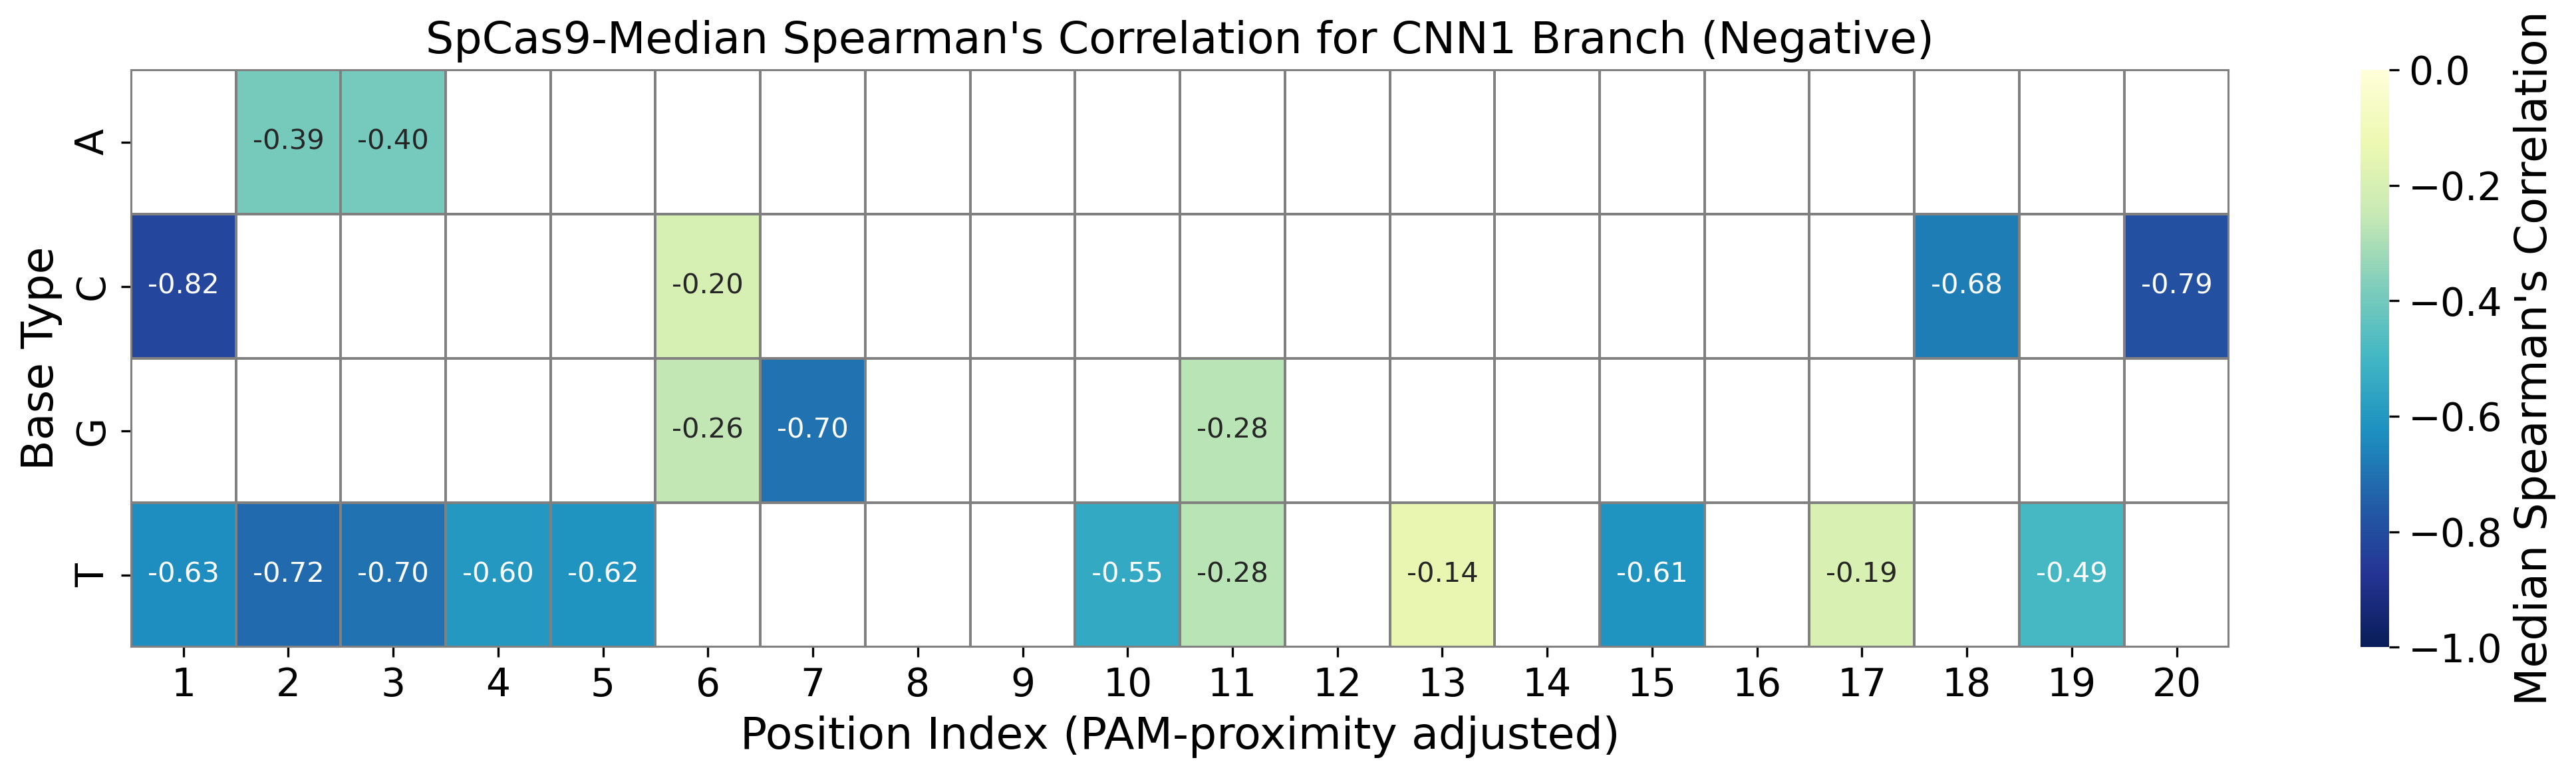

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("indiv_features_with_negative_IQR_Cas9_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)
heatmap_data = heatmap_data.loc[:, heatmap_data.columns[::-1]]

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu_r",
    vmin=-1,
    vmax=0,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)

# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("SpCas9-Median Spearman's Correlation for CNN1 Branch (Negative)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()
